# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

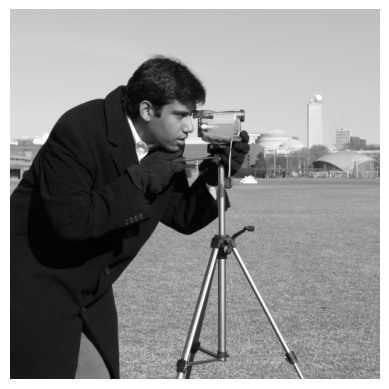

In [12]:
img1 = Image.fromarray(data.camera())
img1.save("original_img1.png")
img1 = Image.fromarray(data.camera())

plt.imshow(img1, cmap='gray')
plt.axis('off')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [13]:
# Get the size of the image
width, height = img1.size

# scaling factors
scale=2

In [18]:
# ── 1. Increase size (scale ×2) ────────────────────
width, height = img1.size
# Resize the image using PIL's built-in method
new_size = (width * scale, height * scale)
scaled_img = img1.resize(new_size,Image.Resampling.LANCZOS)


Original size: (512, 512)
Scaled size: (1024, 512)


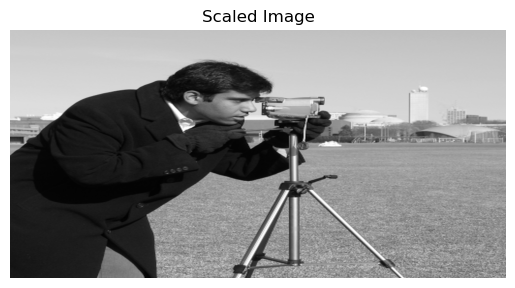

In [25]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img1.size)
print("Scaled size:", scaled_img.size)
plt.imshow(scaled_img, cmap='gray')
plt.title("Scaled Image")
plt.axis('off')
plt.show()

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [20]:
cx = 2
cy = 1

In [21]:
width, height = img1.size
new_size = (int(width * cx), int(height * cy))

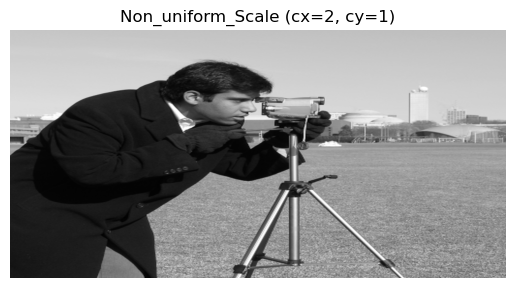

In [31]:
Non_uniform_Scale = img1.resize(new_size, Image.Resampling.LANCZOS)

plt.imshow(Non_uniform_Scale, cmap='gray')
plt.title("Non_uniform_Scale (cx=2, cy=1)")
plt.axis('off')
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


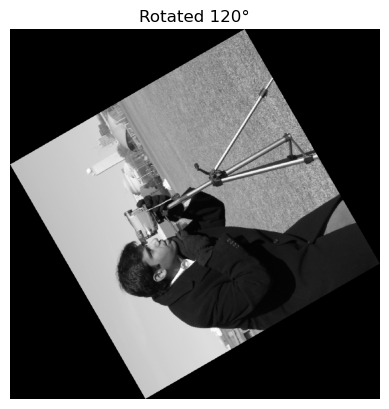

In [26]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img1.rotate(120, expand=True)

rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img1.size)
print("Rotated size:", rotated_img.size)
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 120°")
plt.axis('off')
plt.show()


### 3. Shear

In [24]:
# -- c. Get the image dimensions ────────────────────
width, height = img1.size
print("Width:", width)
print("Height:", height)

Width: 512
Height: 512


In [32]:
# -- d. define the shear matrix ──────────────────────────
# ChooseX-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear = 0.5
shear_matrix = np.array([[1, shear], [0, 1]])

In [36]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

w, h = img1.size

sheared_img = img1.transform(
    (w, h),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0)
)

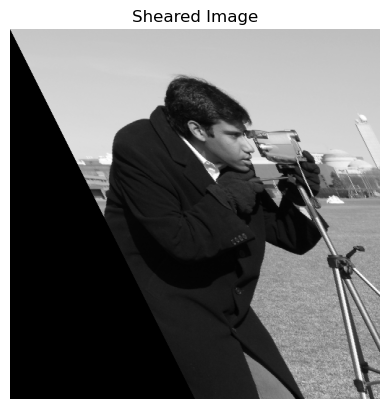

In [35]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")
plt.imshow(sheared_img, cmap='gray')
plt.title("Sheared Image")
plt.axis('off')
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

##### different X-axis shear factors

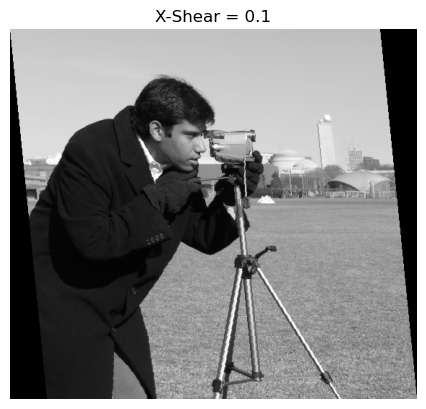

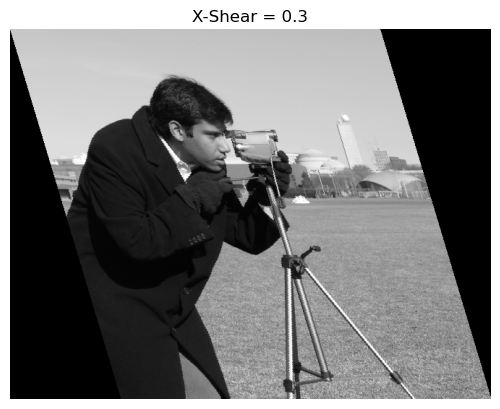

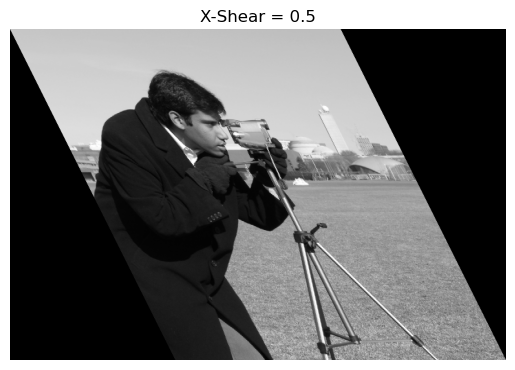

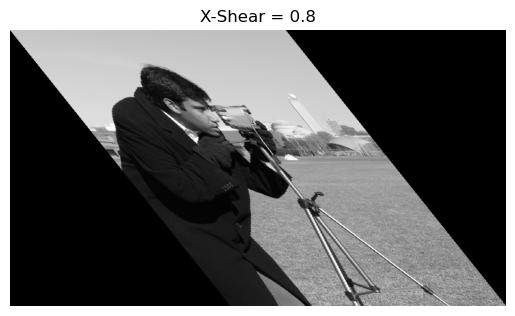

In [45]:
for shx in [0.1, 0.3, 0.5, 0.8]:
    w, h = img1.size
    canvas = (int(w * (1 + shx)), h)

    sheared = img1.transform(
        canvas,
        Image.Transform.AFFINE,
        (1, -shx, 0, 0, 1, 0)
    )

    plt.imshow(sheared, cmap='gray')
    plt.title(f"X-Shear = {shx}")
    plt.axis('off')
    plt.show()

##### different Y-axis shear factors

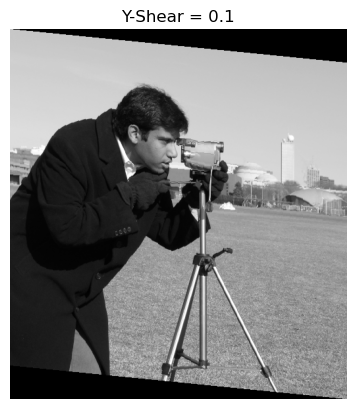

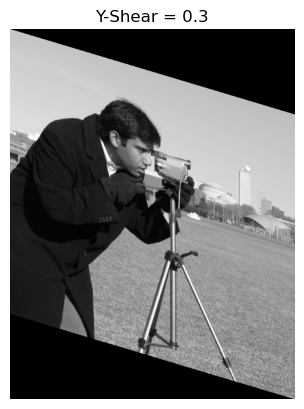

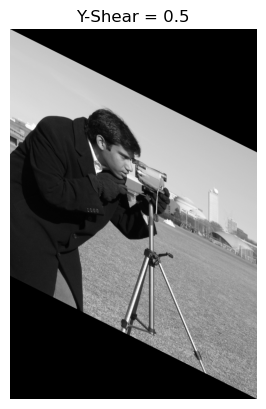

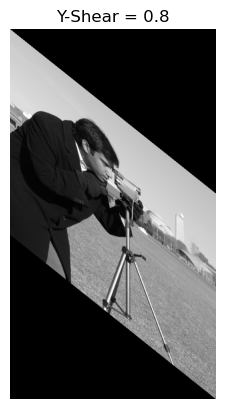

In [50]:
for shy in [0.1, 0.3, 0.5, 0.8]:
    w, h = img1.size
    canvas = (w, int(h * (1 + shy)))

    sheared_y = img1.transform(
        canvas,
        Image.Transform.AFFINE,
        (1, 0, 0, -shy, 1, 0)
    )

    plt.imshow(sheared_y, cmap='gray')
    plt.title(f"Y-Shear = {shy}")
    plt.axis('off')
    plt.show()

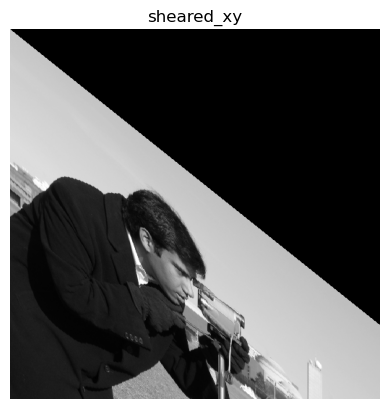

In [44]:
shx = 0.5
shy = 0.3

sheared_xy = img1.transform(
    img1.size,
    Image.Transform.AFFINE,
    (1, -shx, 0, -shy, 1, 0)
)
plt.imshow(sheared_y, cmap='gray')
plt.title("sheared_xy")
plt.axis('off')
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

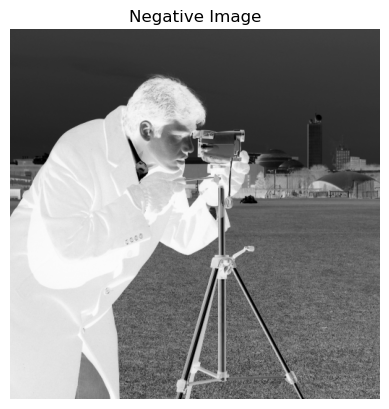

In [51]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
negative = 255 - np.array(img1)

plt.imshow(negative, cmap='gray')
plt.title("Negative Image")
plt.axis('off')
plt.show()



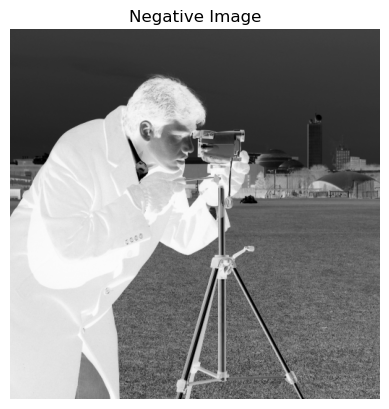

In [52]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative = ImageOps.invert(img1)

plt.imshow(negative, cmap='gray')
plt.title("Negative Image")
plt.axis('off')
plt.show()

C:\Users\Fatimah\AppData\Local\Temp\ipykernel_26496\2738381447.py:11: RuntimeWarning: divide by zero encountered in log
  log_img = c * np.log(1 + img_array)
C:\Users\Fatimah\AppData\Local\Temp\ipykernel_26496\2738381447.py:12: RuntimeWarning: invalid value encountered in cast
  log_img = np.uint8(log_img)


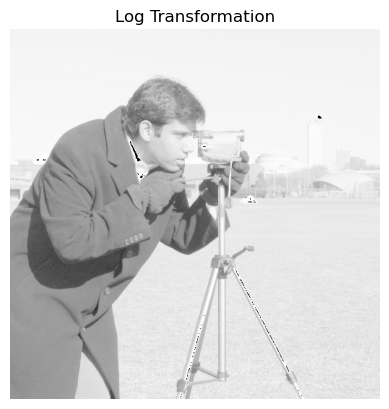

In [53]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
img_array = np.array(img1)
c = 255 / np.log(256)

# Apply the log transformation to each pixel
log_img = c * np.log(1 + img_array)
log_img = np.uint8(log_img)

plt.imshow(log_img, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()

In [ ]:

# ── 3. Power-law / Gamma correction ───────────────
